# Notebook for plotting evaluation metrics for drone swarm

Structure of the drone_data:

[# neighbors, avg neighbors dist, distance weight convex hull, viewing error, viewing coverage]

## Metrics definition
1. Neighbors average

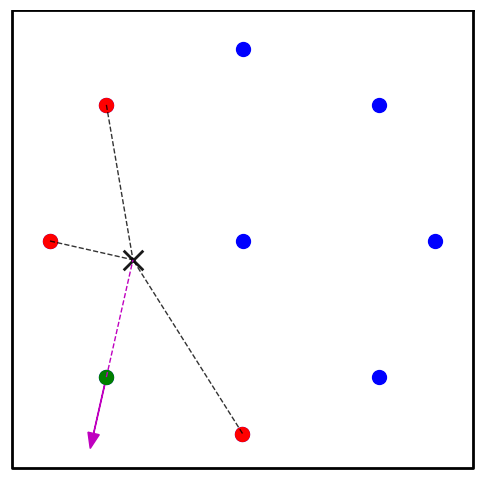

In [191]:
# Simple average of neighbors
import numpy as np
import matplotlib.pyplot as plt

BOUND = 0.6
SIZE = 100
# 8 drones on a circle + 1 in the center
n = 9
r = 0.5
# neighbors
neighbors = [4,5,7]
selected = 6
# positions
x = [0] + [r*np.cos(2*np.pi*i/(n-1)) for i in range(n-1)]
y = [0] + [r*np.sin(2*np.pi*i/(n-1)) for i in range(n-1)]

# Set figure
plt.figure(figsize=(6,6))
plt.axis('equal')

plt.axis([-BOUND, BOUND, -BOUND, BOUND])
# Hide axes
plt.axis('off')
# Scatter plot
plt.scatter(x, y, marker='o', color='b', s=SIZE)
plt.scatter([x[i] for i in neighbors], [y[i] for i in neighbors], marker='o', color='r', s=SIZE)

# Show neighbors centroid
x_center = np.mean([x[i] for i in neighbors])
y_center = np.mean([y[i] for i in neighbors])
plt.scatter(x_center, y_center, marker='x', color=[[0,0,0,0.90]], s=200, linewidth=2)

# Draw dotted line from neighbors to centroid
for i in neighbors:
    plt.plot([x[i], x_center], [y[i], y_center], 'k--', alpha=0.8, lw=1)

# Draw dotted line from selected to centroid
plt.plot([x[selected], x_center], [y[selected], y_center], 'm--', lw=1)

# Draw pointing arrow
dir = np.array([x_center - x[selected], y_center - y[selected]])
dir = dir / np.linalg.norm(dir)
plt.arrow(x[selected], y[selected], -dir[0]*0.15, -dir[1]*0.15, head_width=0.03, head_length=0.04, fc='m', ec='m')

plt.scatter(x[selected], y[selected], marker='o', color='g', s=SIZE)

# Create a box around the plot
plt.plot([BOUND, BOUND, -BOUND, -BOUND, BOUND], [BOUND, -BOUND+0.01, -BOUND+0.01, BOUND, BOUND], 'k-', lw=2)


2. Convex Hull

CONVEX HULL ADJACENT


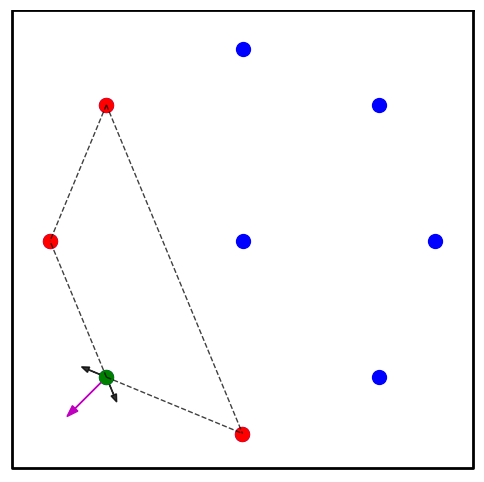

In [190]:
import numpy as np
import matplotlib.pyplot as plt

BOUND = 0.6
SIZE = 100
# 8 drones on a circle + 1 in the center
n = 9
r = 0.5
# neighbors
neighbors = [4,5,7]
selected = 6
# positions
x = [0] + [r*np.cos(2*np.pi*i/(n-1)) for i in range(n-1)]
y = [0] + [r*np.sin(2*np.pi*i/(n-1)) for i in range(n-1)]

# Set figure
plt.figure(figsize=(6,6))
plt.axis('equal')

plt.axis([-BOUND, BOUND, -BOUND, BOUND])
# Hide axes
plt.axis('off')
# Show convex hull of neighbors including selected drone
from scipy.spatial import ConvexHull
points = np.array([[x[i], y[i]] for i in neighbors] + [[x[selected], y[selected]]])
hull = ConvexHull(points)
for simplex in hull.simplices:
    plt.plot(points[simplex, 0], points[simplex, 1], 'k--', alpha=0.75, lw=1)

# Scatter plot
plt.scatter(x, y, marker='o', color='b', s=SIZE)
plt.scatter([x[i] for i in neighbors], [y[i] for i in neighbors], marker='o', color='r', s=SIZE)

# Show arrows for adjacent edges of selected
# Select edges of selected drone
adjacent = [5,7]
# Draw arrows
final_dir = np.zeros(2)
for i in adjacent:
    dir = np.array([x[i] - x[selected], y[i] - y[selected]])
    dir = -dir / np.linalg.norm(dir)
    final_dir += dir
    plt.arrow(x[selected], y[selected], dir[0]*0.05, dir[1]*0.05, head_width=0.015, head_length=0.02, fc='k', ec='k', alpha=0.8)
# # Draw pointing arrow
plt.arrow(x[selected], y[selected], final_dir[0]*0.15, final_dir[1]*0.15, head_width=0.02, head_length=0.03, fc='m', ec='m')

plt.scatter(x[selected], y[selected], marker='o', color='g', s=SIZE)

print("CONVEX HULL ADJACENT")

# Create a box around the plot
plt.plot([BOUND, BOUND, -BOUND, -BOUND, BOUND], [BOUND, -BOUND+0.01, -BOUND+0.01, BOUND, BOUND], 'k-', lw=2)


CONVEX HULL VISIBLE


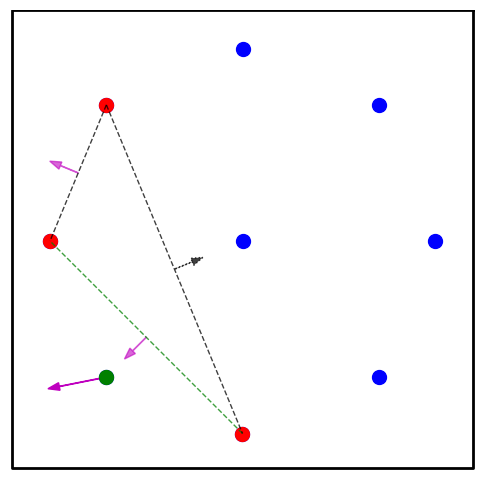

In [188]:
import numpy as np
import matplotlib.pyplot as plt

BOUND = 0.6
SIZE = 100
# 8 drones on a circle + 1 in the center
n = 9
r = 0.5
# neighbors
neighbors = [4,5,7]
selected = 6
# positions
x = [0] + [r*np.cos(2*np.pi*i/(n-1)) for i in range(n-1)]
y = [0] + [r*np.sin(2*np.pi*i/(n-1)) for i in range(n-1)]

# Set figure
plt.figure(figsize=(6,6))
plt.axis('equal')

plt.axis([-BOUND, BOUND, -BOUND, BOUND])
# Hide axes
plt.axis('off')
# Show convex hull of neighbors including selected drone
from scipy.spatial import ConvexHull
points = np.array([[x[i], y[i]] for i in neighbors])
hull = ConvexHull(points)

# Show edges normal using hull equations
hull_centroids = np.mean(points[hull.simplices], axis=1)
# Find closest to the drone
drone_pos = np.array([x[selected], y[selected]])
closest_idx = np.argmin(np.linalg.norm(hull_centroids - drone_pos, axis=1))
closest_normal = hull.equations[closest_idx, :2]

# for simplex in hull.simplices:
#     plt.plot(points[simplex, 0], points[simplex, 1], 'k--', alpha=0.75, lw=1)

visible_normals = []
for i in range(len(hull.equations)):
    # draw edge
    plt.plot([points[hull.simplices[i, 0], 0], points[hull.simplices[i, 1], 0]], [points[hull.simplices[i, 0], 1], points[hull.simplices[i, 1], 1], ], 'k--' if i != closest_idx else 'g--', alpha=0.75, lw=1)
    x0 = hull_centroids[i, 0]
    y0 = hull_centroids[i, 1]
    a = hull.equations[i, 0]
    b = hull.equations[i, 1]
    if np.dot(hull.equations[i, :2], closest_normal) > 0:
        visible_normals.append(hull.equations[i, :2])
        # Draw normal
        plt.arrow(x0, y0, a*0.05, b*0.05, head_width=0.02, head_length=0.03, fc='m', ec='m', alpha=0.6)
    else:
        plt.arrow(x0, y0, a*0.05, b*0.05, head_width=0.02, head_length=0.03, fc='k', ec='k', alpha=0.75, linestyle=':', linewidth=1)


# Scatter plot
plt.scatter(x, y, marker='o', color='b', s=SIZE)
plt.scatter([x[i] for i in neighbors], [y[i] for i in neighbors], marker='o', color='r', s=SIZE)

# # Draw pointing arrow
final_dir = np.mean(visible_normals, axis=0)
plt.arrow(x[selected], y[selected], final_dir[0]*0.15, final_dir[1]*0.15, head_width=0.02, head_length=0.03, fc='m', ec='m')

plt.scatter(x[selected], y[selected], marker='o', color='g', s=SIZE)

print("CONVEX HULL VISIBLE")
# Create a box around the plot
plt.plot([BOUND, BOUND, -BOUND, -BOUND, BOUND], [BOUND, -BOUND+0.01, -BOUND+0.01, BOUND, BOUND], 'k-', lw=2)


3. Outer

In [187]:
import matplotlib.pyplot as plt
import numpy as np

from matplotlib.patches import Arc
from matplotlib.transforms import Bbox, IdentityTransform, TransformedBbox


class AngleAnnotation(Arc):
    """
    Draws an arc between two vectors which appears circular in display space.
    """
    def __init__(self, xy, p1, p2, size=75, unit="points", ax=None,
                 text="", textposition="inside", text_kw=None, **kwargs):
        """
        Parameters
        ----------
        xy, p1, p2 : tuple or array of two floats
            Center position and two points. Angle annotation is drawn between
            the two vectors connecting *p1* and *p2* with *xy*, respectively.
            Units are data coordinates.

        size : float
            Diameter of the angle annotation in units specified by *unit*.

        unit : str
            One of the following strings to specify the unit of *size*:

            * "pixels": pixels
            * "points": points, use points instead of pixels to not have a
              dependence on the DPI
            * "axes width", "axes height": relative units of Axes width, height
            * "axes min", "axes max": minimum or maximum of relative Axes
              width, height

        ax : `matplotlib.axes.Axes`
            The Axes to add the angle annotation to.

        text : str
            The text to mark the angle with.

        textposition : {"inside", "outside", "edge"}
            Whether to show the text in- or outside the arc. "edge" can be used
            for custom positions anchored at the arc's edge.

        text_kw : dict
            Dictionary of arguments passed to the Annotation.

        **kwargs
            Further parameters are passed to `matplotlib.patches.Arc`. Use this
            to specify, color, linewidth etc. of the arc.

        """
        self.ax = ax or plt.gca()
        self._xydata = xy  # in data coordinates
        self.vec1 = p1
        self.vec2 = p2
        self.size = size
        self.unit = unit
        self.textposition = textposition

        super().__init__(self._xydata, size, size, angle=0.0,
                         theta1=self.theta1, theta2=self.theta2, **kwargs)

        self.set_transform(IdentityTransform())
        self.ax.add_patch(self)

        self.kw = dict(ha="center", va="center",
                       xycoords=IdentityTransform(),
                       xytext=(0, 0), textcoords="offset points",
                       annotation_clip=True)
        self.kw.update(text_kw or {})
        self.text = ax.annotate(text, xy=self._center, **self.kw)

    def get_size(self):
        factor = 1.
        if self.unit == "points":
            factor = self.ax.figure.dpi / 72.
        elif self.unit[:4] == "axes":
            b = TransformedBbox(Bbox.unit(), self.ax.transAxes)
            dic = {"max": max(b.width, b.height),
                   "min": min(b.width, b.height),
                   "width": b.width, "height": b.height}
            factor = dic[self.unit[5:]]
        return self.size * factor

    def set_size(self, size):
        self.size = size

    def get_center_in_pixels(self):
        """return center in pixels"""
        return self.ax.transData.transform(self._xydata)

    def set_center(self, xy):
        """set center in data coordinates"""
        self._xydata = xy

    def get_theta(self, vec):
        vec_in_pixels = self.ax.transData.transform(vec) - self._center
        return np.rad2deg(np.arctan2(vec_in_pixels[1], vec_in_pixels[0]))

    def get_theta1(self):
        return self.get_theta(self.vec1)

    def get_theta2(self):
        return self.get_theta(self.vec2)

    def set_theta(self, angle):
        pass

    # Redefine attributes of the Arc to always give values in pixel space
    _center = property(get_center_in_pixels, set_center)
    theta1 = property(get_theta1, set_theta)
    theta2 = property(get_theta2, set_theta)
    width = property(get_size, set_size)
    height = property(get_size, set_size)
    # The following two methods are needed to update the text position.
    def draw(self, renderer):
        self.update_text()
        super().draw(renderer)

    def update_text(self):
        c = self._center
        s = self.get_size()
        angle_span = (self.theta2 - self.theta1) % 360
        angle = np.deg2rad(self.theta1 + angle_span / 2)
        r = s / 2
        if self.textposition == "inside":
            r = s / np.interp(angle_span, [60, 90, 135, 180],
                                          [3.3, 3.5, 3.8, 4])
        self.text.xy = c + r * np.array([np.cos(angle), np.sin(angle)])
        if self.textposition == "outside":
            def R90(a, r, w, h):
                if a < np.arctan(h/2/(r+w/2)):
                    return np.sqrt((r+w/2)**2 + (np.tan(a)*(r+w/2))**2)
                else:
                    c = np.sqrt((w/2)**2+(h/2)**2)
                    T = np.arcsin(c * np.cos(np.pi/2 - a + np.arcsin(h/2/c))/r)
                    xy = r * np.array([np.cos(a + T), np.sin(a + T)])
                    xy += np.array([w/2, h/2])
                    return np.sqrt(np.sum(xy**2))

            def R(a, r, w, h):
                aa = (a % (np.pi/4))*((a % (np.pi/2)) <= np.pi/4) + \
                     (np.pi/4 - (a % (np.pi/4)))*((a % (np.pi/2)) >= np.pi/4)
                return R90(aa, r, *[w, h][::int(np.sign(np.cos(2*a)))])

            bbox = self.text.get_window_extent()
            X = R(angle, r, bbox.width, bbox.height)
            trans = self.ax.figure.dpi_scale_trans.inverted()
            offs = trans.transform(((X-s/2), 0))[0] * 72
            self.text.set_position([offs*np.cos(angle), offs*np.sin(angle)])

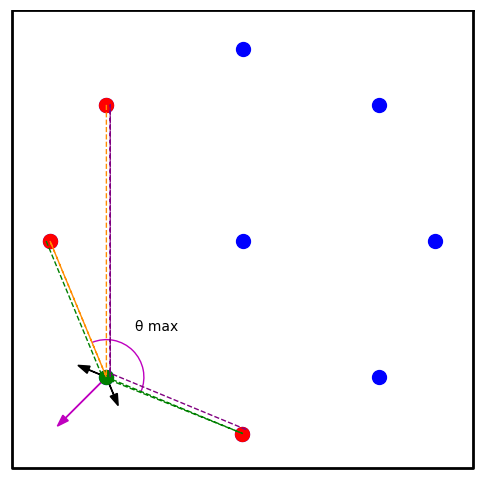

In [183]:
# Outer 2
import numpy as np
import matplotlib.pyplot as plt

BOUND = 0.6
SIZE = 100
# 8 drones on a circle + 1 in the center
n = 9
r = 0.5
# neighbors
neighbors = [4,5,7]
selected = 6
# positions
x = [0] + [r*np.cos(2*np.pi*i/(n-1)) for i in range(n-1)]
y = [0] + [r*np.sin(2*np.pi*i/(n-1)) for i in range(n-1)]

# Set figure
fig = plt.figure(figsize=(6,6))
plt.axis('equal')

plt.axis([-BOUND, BOUND, -BOUND, BOUND])
# Hide axes
plt.axis('off')
# Scatter plot
plt.scatter(x, y, marker='o', color='b', s=SIZE)
plt.scatter([x[i] for i in neighbors], [y[i] for i in neighbors], marker='o', color='r', s=SIZE)

# Find max angle between pairs of 2 neighbors and selected drone
# Draw combinations with lines
plt.plot([x[neighbors[0]], x[selected], x[neighbors[1]], x[selected]], [y[neighbors[0]], y[selected], y[neighbors[1]], y[selected]], c='darkorange', linestyle='--', lw=1)
plt.plot([x[neighbors[1]]-0.01, x[selected]-0.01, x[neighbors[2]], x[selected]], [y[neighbors[1]], y[selected], y[neighbors[2]], y[selected]], c='green', linestyle='--', lw=1)
plt.plot([x[neighbors[2]]+0.01, x[selected]+0.01, x[neighbors[0]]+0.01, x[selected]+0.01], [y[neighbors[2]]+0.01, y[selected]+0.01, y[neighbors[0]], y[selected]], c='purple', linestyle='--', lw=1)

# Show arrows for max angle edges
dir = np.array([x[neighbors[1]] - x[selected], y[neighbors[1]] - y[selected]])
dir = -dir / np.linalg.norm(dir)
plt.arrow(x[selected], y[selected], dir[0]*0.05, dir[1]*0.05, head_width=0.02, head_length=0.03, fc='k', ec='k')
dir2 = np.array([x[neighbors[2]] - x[selected], y[neighbors[2]] - y[selected]])
dir2 = -dir2 / np.linalg.norm(dir2)
plt.arrow(x[selected], y[selected], dir2[0]*0.05, dir2[1]*0.05, head_width=0.02, head_length=0.03, fc='k', ec='k')

# Draw pointing arrow
final_dir = (dir + dir2) / 2
final_dir = final_dir / np.linalg.norm(final_dir)
plt.arrow(x[selected], y[selected], final_dir[0]*0.15, final_dir[1]*0.15, head_width=0.02, head_length=0.03, fc='m', ec='m')

# Add angle anotation
AngleAnnotation(xy=(x[selected], y[selected]), p2=(x[neighbors[1]], y[neighbors[1]]), p1=(x[neighbors[2]], y[neighbors[2]]), size=75, ax=fig.gca(), color='m', text="θ max", textposition="outside", text_kw={"color": "k"})

plt.scatter(x[selected], y[selected], marker='o', color='g', s=SIZE)

# Create a box around the plot
plt.plot([BOUND, BOUND, -BOUND, -BOUND, BOUND], [BOUND, -BOUND+0.01, -BOUND+0.01, BOUND, BOUND], 'k-', lw=2)

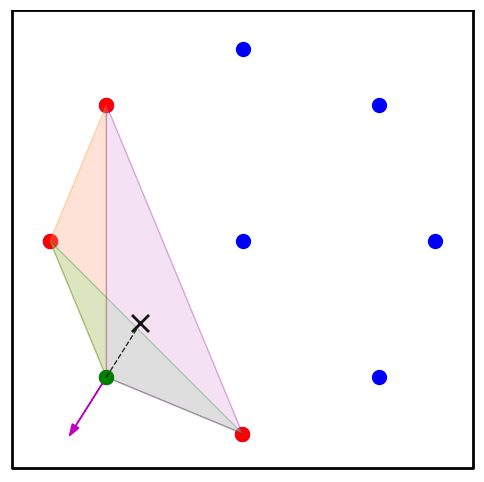

In [199]:
# Outer 3
import numpy as np
import matplotlib.pyplot as plt

BOUND = 0.6
SIZE = 100
# 8 drones on a circle + 1 in the center
n = 9
r = 0.5
# neighbors
neighbors = [4,5,7]
selected = 6
# positions
x = [0] + [r*np.cos(2*np.pi*i/(n-1)) for i in range(n-1)]
y = [0] + [r*np.sin(2*np.pi*i/(n-1)) for i in range(n-1)]

# Set figure
fig = plt.figure(figsize=(6,6))
plt.axis('equal')

plt.axis([-BOUND, BOUND, -BOUND, BOUND])
# Hide axes
plt.axis('off')
# Scatter plot
plt.scatter(x, y, marker='o', color='b', s=SIZE)
plt.scatter([x[i] for i in neighbors], [y[i] for i in neighbors], marker='o', color='r', s=SIZE)

# Draw sets of triangles with neighbors
t1 = np.array([[x[selected], y[selected]], [x[neighbors[0]], y[neighbors[0]]], [x[neighbors[1]], y[neighbors[1]]], [x[selected], y[selected]]])
t2 = np.array([[x[selected], y[selected]], [x[neighbors[1]], y[neighbors[1]]], [x[neighbors[2]], y[neighbors[2]]], [x[selected], y[selected]]])
t3 = np.array([[x[selected], y[selected]], [x[neighbors[2]], y[neighbors[2]]], [x[neighbors[0]], y[neighbors[0]]], [x[selected], y[selected]]])
plt.fill(t1[:, 0], t1[:, 1], facecolor='lightsalmon', edgecolor='darkorange', alpha=0.3)
plt.fill(t2[:, 0], t2[:, 1], facecolor='lightgreen', edgecolor='green', alpha=0.3)
plt.fill(t3[:, 0], t3[:, 1], facecolor='plum', edgecolor='purple', alpha=0.3)

# find centroid of triangle
centroid = np.mean(t3, axis=0)
plt.scatter(centroid[0], centroid[1], marker='x', color=[[0,0,0,0.90]], s=150, linewidth=2)
plt.plot([x[selected], centroid[0]], [y[selected], centroid[1]], 'k--', lw=1, alpha=0.8)

# Draw pointing arrow
final_dir = np.array([centroid[0] - x[selected], centroid[1] - y[selected]])
final_dir = - final_dir / np.linalg.norm(final_dir)
plt.arrow(x[selected], y[selected], final_dir[0]*0.15, final_dir[1]*0.15, head_width=0.02, head_length=0.03, fc='m', ec='m')


plt.scatter(x[selected], y[selected], marker='o', color='g', s=SIZE)

# Create a box around the plot
plt.plot([BOUND, BOUND, -BOUND, -BOUND, BOUND], [BOUND, -BOUND+0.01, -BOUND+0.01, BOUND, BOUND], 'k-', lw=2)

4. Tangent plane

[0.04587585 0.45412415]
[[-0.88807383  0.45970084]
 [-0.45970084 -0.88807383]]


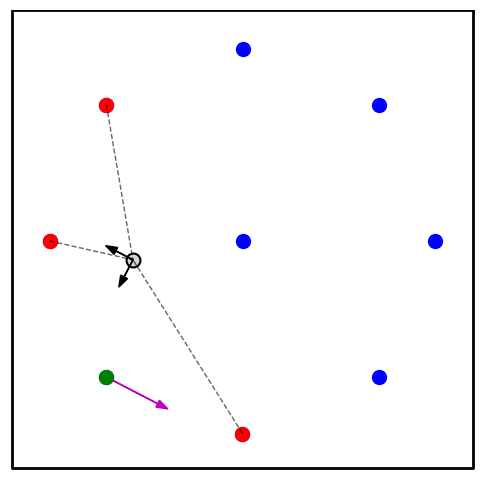

In [194]:
# Outer 3
import numpy as np
import matplotlib.pyplot as plt

BOUND = 0.6
SIZE = 100
# 8 drones on a circle + 1 in the center
n = 9
r = 0.5
# neighbors
neighbors = [4,5,7]
selected = 6
# positions
x = [0] + [r*np.cos(2*np.pi*i/(n-1)) for i in range(n-1)]
y = [0] + [r*np.sin(2*np.pi*i/(n-1)) for i in range(n-1)]

# Set figure
fig = plt.figure(figsize=(6,6))
plt.axis('equal')

plt.axis([-BOUND, BOUND, -BOUND, BOUND])
# Hide axes
plt.axis('off')
# Scatter plot
plt.scatter(x, y, marker='o', color='b', s=SIZE)
plt.scatter([x[i] for i in neighbors], [y[i] for i in neighbors], marker='o', color='r', s=SIZE)

neighbors_pos = np.array([[x[i], y[i]] for i in neighbors])
drone_pos = np.array([x[selected], y[selected]])
centroid = np.mean(neighbors_pos, axis=0)
neighbors_centered = neighbors_pos - centroid
cov = np.sum([np.outer(n, n) for n in neighbors_centered], axis=0)
eig_val, eig_vectors = np.linalg.eig(cov)
eig_val, eig_vectors = np.real(eig_val), np.real(eig_vectors)
print(eig_val)
print(eig_vectors)
sorted_indices = np.argsort(eig_val)
normal = eig_vectors[sorted_indices[0]]
if abs(eig_val[sorted_indices[1]] - eig_val[sorted_indices[0]]) < 0.01:
    print("WARNING :: Eigenvalues are too close to each other, averaging the two smallest")
    normal = np.mean(eig_vectors[sorted_indices[:2]], axis=0)

viewing_dir = -np.sign(np.dot(normal, centroid-drone_pos))*normal

# Show arrows for eigenvectors
plt.scatter(centroid[0], centroid[1], marker='o', color='k', s=100, linestyle='-', facecolor='lightgray', linewidth=1.5)
# draw lines to centroid
for i in range(len(neighbors)):
    plt.plot([x[neighbors[i]], centroid[0]], [y[neighbors[i]], centroid[1]], 'k--', alpha=0.6, lw=1)
dir = eig_vectors[sorted_indices[0]]
plt.arrow(centroid[0], centroid[1], dir[0]*0.05, dir[1]*0.05, head_width=0.02, head_length=0.03, fc='k', ec='k')
dir2 = eig_vectors[sorted_indices[1]]
plt.arrow(centroid[0], centroid[1], dir2[0]*0.05, dir2[1]*0.05, head_width=0.02, head_length=0.03, fc='k', ec='k')

# Draw pointing arrow
final_dir = viewing_dir
final_dir = final_dir / np.linalg.norm(final_dir)
plt.arrow(x[selected], y[selected], final_dir[0]*0.15, final_dir[1]*0.15, head_width=0.02, head_length=0.03, fc='m', ec='m')


plt.scatter(x[selected], y[selected], marker='o', color='g', s=SIZE)

# Create a box around the plot
plt.plot([BOUND, BOUND, -BOUND, -BOUND, BOUND], [BOUND, -BOUND+0.01, -BOUND+0.01, BOUND, BOUND], 'k-', lw=2)

ValueError: shapes (27,) and (3,9) not aligned: 27 (dim 0) != 3 (dim 0)

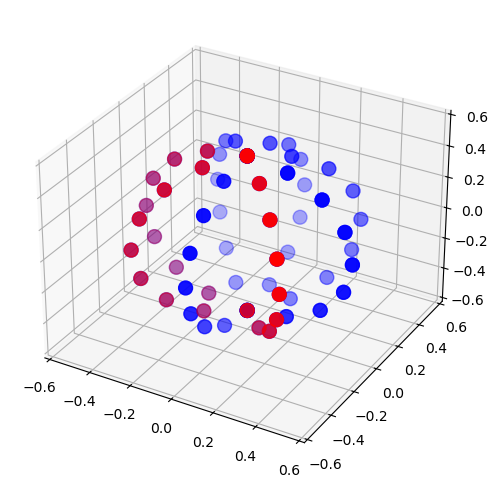

In [174]:
# 3D tangent plane viewing dir
import numpy as np
import matplotlib.pyplot as plt

BOUND = 0.6
SIZE = 100
# 8 drones on a sphere + 1 in the center
n = 9
r = 0.5
# neighbors
neighbors = [4,5,7]
selected = 6
# positions distibuted on a sphere
theta = np.linspace(0, np.pi, n)
phi = np.linspace(0, 2*np.pi, n)
theta, phi = np.meshgrid(theta, phi)
x = r*np.sin(theta)*np.cos(phi)
y = r*np.sin(theta)*np.sin(phi)
z = r*np.cos(theta)

# Set figure
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

ax.set_xlim([-BOUND, BOUND])
ax.set_ylim([-BOUND, BOUND])
ax.set_zlim([-BOUND, BOUND])
# Hide axes
# ax.axis('off')
# Scatter plot
ax.scatter(x, y, z, marker='o', color='b', s=SIZE)
ax.scatter([x[i] for i in neighbors], [y[i] for i in neighbors], [z[i] for i in neighbors], marker='o', color='r', s=SIZE)

neighbors_pos = np.array([[x[i], y[i], z[i]] for i in neighbors])
drone_pos = np.array([x[selected], y[selected], z[selected]])
centroid = np.mean(neighbors_pos, axis=0)
neighbors_centered = neighbors_pos - centroid
cov = np.sum([np.outer(n, n) for n in neighbors_centered], axis=0)
eig_val, eig_vectors = np.linalg.eig(cov)
eig_val, eig_vectors = np.real(eig_val), np.real(eig_vectors)
sorted_indices = np.argsort(eig_val)
normal = eig_vectors[sorted_indices[0]]
if abs(eig_val[sorted_indices[1]] - eig_val[sorted_indices[0]]) < 0.01:
    print("WARNING :: Eigenvalues are too close to each other, averaging the two smallest")
    normal = np.mean(eig_vectors[sorted_indices[:2]], axis=0)

viewing_dir = -np.sign(np.dot(normal, centroid-drone_pos))*normal

# Show arrows for eigenvectors
ax.scatter(centroid[0], centroid[1], centroid[2], marker='o', color='k', s=100, linestyle='-', facecolor='lightgray', linewidth=1.5)
# draw lines to centroid
for i in range(len(neighbors)):
    ax.plot([x[neighbors[i]], centroid[0]], [y[neighbors[i]], centroid[1]], [z[neighbors[i]], centroid[2]], 'k--', alpha=0.6, lw=1)

dir = eig_vectors[sorted_indices[0]]
ax.quiver(centroid[0], centroid[1], centroid[2], dir[0]*0.05, dir[1]*0.05, dir[2]*0.05, color='k')
dir2 = eig_vectors[sorted_indices[1]]
ax.quiver(centroid[0], centroid[1], centroid[2], dir2[0]*0.05, dir2[1]*0.05, dir2[2]*0.05, color='k')

# Draw pointing arrow
final_dir = viewing_dir
final_dir = final_dir / np.linalg.norm(final_dir)
ax.quiver(x[selected], y[selected], z[selected], final_dir[0]*0.15, final_dir[1]*0.15, final_dir[2]*0.15, color='m')


ax.scatter(x[selected], y[selected], z[selected], marker='o', color='g', s=SIZE)





## First test: Outter vs Convex Hull viewing metric
Keeping neighbors metric to topological, # drones to 10

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize

%matplotlib qt
# Read data dict
FILEPATH = "sim_results/2D_outter3/2D_outter3_topological_{0}.npy"
from_ = 3
to = 9
NB_TESTS = to - from_ + 1
data = []
timing_data = []
try:
    for i in range(from_, to+1):
        data.append(np.load(FILEPATH.format(i), allow_pickle=True).item())
except FileNotFoundError:
    print('File not found')

min_data_len = np.min([len(d['drone_data']) for d in data])
all_drone_data = np.array([d['drone_data'][:min_data_len] for d in data])
timings = np.array([d['timings'][:min_data_len] for d in data])
swarm_centers = np.array([d['swarm_center'][:min_data_len] for d in data])

In [ ]:
# 1- Plot the drone viewing direction error
fig = plt.figure(figsize=(16, 12))
fig.suptitle('2D swarm with outter (2) viewing metric with topological neighborhood')
ax = fig.add_subplot(2, 2, 1, projection='3d')
ax.set_title('Drones viewing direction error')
# Labelling
ax.set_xlabel('# neighbors')
ax.set_ylabel('Drone index')
ax.set_zlabel('Error')
# Create the bins
nb_drones = data[0]['params']['drone_count']
xpos, ypos = np.meshgrid(np.arange(from_, to+1), np.arange(nb_drones))
xpos = xpos.flatten('F')
ypos = ypos.flatten('F')
zpos = np.zeros_like(xpos)
# Find the average error for each drone
errors = np.mean(all_drone_data[:, :, :, 3], axis=1)

# Construct arrays with the dimensions for the bars.
dx = 0.5 * np.ones_like(xpos)
dy = 0.5 * np.ones_like(ypos)
dz = errors.flatten()

# Create color map with dist to center (on average)
colormap = cm.get_cmap('jet')
dist_to_center = np.mean(np.abs(all_drone_data[:, :, :, 2]), axis=1)
max_height = np.max(dist_to_center)
min_height = np.min(dist_to_center)
dist_to_center = dist_to_center.flatten()
colors = colormap((dist_to_center - min_height) / (max_height-min_height))
ax.bar3d(xpos, ypos, zpos, dx, dy, dz, color=colors, zsort='average')
ax.set_box_aspect(aspect=None, zoom=0.95)
cbar = plt.colorbar(cm.ScalarMappable(Normalize(vmin=min_height, vmax=max_height), cmap=colormap), ax=ax, orientation='vertical')
cbar.set_label('Avg dist to swarm center')

# Add average over all drones as 2d line
avg_errors = np.mean(errors, axis=1)
ax.plot(np.arange(from_, to+1), avg_errors, zs=10, zdir='y', color='black', label='Avg error', linewidth=2)
ax.legend()

# 2- Plot the average coverage
# fig2 = plt.figure(figsize=(8, 6))
# fig2.suptitle('Average coverage')
ax2 = fig.add_subplot(2, 2, 2)
ax2.set_title('Mean and std of the coverage')
ax2.set_xlabel('# neighbors')
ax2.set_ylabel('Coverage %')
# Find the average coverage for each drone
coverage_mean = np.mean(all_drone_data[:, :, 0, 4], axis=1)
coverage_std = np.std(all_drone_data[:, :, 0, 4], axis=1)
ax2.errorbar(np.arange(from_, to+1), coverage_mean*100, yerr=[coverage_std*100, np.clip(coverage_std, 0, 1-coverage_mean)*100], fmt='k--', label='Coverage', markersize=10, marker='o', ecolor='red', capsize=5, capthick=2)
ax2.legend()

# 3- Plot the different timings
# fig3 = plt.figure(figsize=(8, 6))
# fig3.suptitle('Timings')
ax3 = fig.add_subplot(2, 2, 3)
ax3.set_title('Timings')
ax3.set_xlabel('# neighbors')
ax3.set_ylabel('Computation time (ms)')
# Compute average timings
timings_neighborhood = np.mean(timings[:, :, 0], axis=1)*1000
timings_viewing = np.mean(timings[:, :, 1], axis=1)*1000
timings_coverage = np.mean(timings[:, :, 2], axis=1)*1000
timings_total = timings_neighborhood + timings_viewing + timings_coverage

x_values = np.arange(from_, to+1)
ax3.bar(x_values, timings_neighborhood, width=0.6, label='Neighborhood')
ax3.bar(x_values, timings_viewing, width=0.6, label='Viewing', bottom=timings_neighborhood)
ax3.bar(x_values, timings_coverage, width=0.6, label='Coverage', bottom=timings_neighborhood+timings_viewing)
for i in range(to-from_+1):
    value = round(timings_neighborhood[i]/timings_total[i] ,2)
    ax3.text(x_values[i], timings_neighborhood[i]/2, value, ha = 'center')
    value = round(timings_viewing[i]/timings_total[i] ,2)
    ax3.text(x_values[i], timings_neighborhood[i]+timings_viewing[i]/2, value, ha = 'center')
    value = round(timings_coverage[i]/timings_total[i] ,2)
    ax3.text(x_values[i], timings_neighborhood[i]+timings_viewing[i]+timings_coverage[i]/2, value, ha = 'center')
ax3.legend()

# Plot the swarm center position over time
# fig4 = plt.figure(figsize=(8, 6))
# fig4.suptitle('Swarm center position')
ax4 = fig.add_subplot(2, 2, 4)
ax4.set_title('Swarm center position')
ax4.set_xlabel('x')
ax4.set_ylabel('y')
# Compute center x,y
center_x = swarm_centers[:, :, 0]
center_y = swarm_centers[:, :, 1]
print(center_x.shape, center_y.shape)
for i in range(center_x.shape[0]):
    ax4.plot(center_x[i, :], center_y[i, :], label=f'Run {i+1}')
# ax4.plot(center_x, center_y, 'b-', linewidth=2)
ax4.grid(True)
ax4.legend()

fig.tight_layout()

(7, 2789) (7, 2789)


C:\Users\alexa\AppData\Local\Temp\ipykernel_5236\171264994.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colormap = cm.get_cmap('jet')


## Second test: Remaining of metrics

The following table summarizes the scheduled tests:


| **Test metric** | **from** | **to** | **incremnents** |       **Fixed parameters**                |  **Cumulative sim run** |
|-----------------|----------|--------|-----------------|-------------------------------------------|-------------------------|
|   # Drones      |     5    |  30    |         5       |    Topological: 3, Average                |           6             |
|   # Drones      |     5    |  30    |         5       |    Topological: 3, Tangeant plane         |           12            |
|   # Drones      |     5    |  30    |         5       |    Topological: 3, Convex Hull (Adjacent) |           18            |
|   # Drones      |     5    |  30    |         5       |    Topological: 3, Convex Hull (Visible)  |           24            |
|   # Drones      |     5    |  30    |         5       |    Visual LoS, Average                    |           30            |
|   # Drones      |     5    |  30    |         5       |    Visual LoS, Tangeant plane             |           36            |
|   # Drones      |     5    |  30    |         5       |    Visual LoS, Convex Hull (Adjacent)     |           42            |
|   # Drones      |     5    |  30    |         5       |    Visual LoS, Convex Hull (Visible)      |           48            |
|   # Drones      |     5    |  30    |         5       |    Voronoi, Average                       |           54            |
|   # Drones      |     5    |  30    |         5       |    Voronoi, Tangeant plane                |           60            |
|   # Drones      |     5    |  30    |         5       |    Voronoi, Convex Hull (Adjacent)        |           66            |
|   # Drones      |     5    |  30    |         5       |    Voronoi, Convex Hull (Visible)         |           72            |
|  # Neighbors    |     2    |  9     |         1       |    Noise: Low (0.01;0.01), Average        |           80            |
|  # Neighbors    |     2    |  9     |         1       |    Noise: Low (0.01;0.01), Tangean plane  |           88            |
|  # Neighbors    |     2    |  9     |         1       |    Noise: Low (0.01;0.01), Convex Hull    |           96            |
|  # Neighbors    |     2    |  9     |         1       |    Noise: Medium (0.025;0.025), Average    |           80            |
|  # Neighbors    |     2    |  9     |         1       |    Noise: Medium (0.025;0.025), Tangean plane |        88            |
|  # Neighbors    |     2    |  9     |         1       |    Noise:Medium (0.025;0.025), Convex Hull |           96            |
|  # Neighbors    |     2    |  9     |         1       |    Noise: High (0.05;0.05), Average        |           102           |
|  # Neighbors    |     2    |  9     |         1       |    Noise: High (0.05;0.05), Tangean plane  |           110           |
|  # Neighbors    |     2    |  9     |         1       |    Noise: High (0.05;0.05), Convex Hull    |           118           |

***NOTE:*** This table should be reproduced twice for 2D and 3D swarm configurations

**Total graphs:** 2*24 = **48**


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize, ListedColormap
import matplotlib as mpl
import os

%matplotlib qt
# Read data dict
FILEPATH = "../sim_results/2D_tests"
sim_files = os.listdir(FILEPATH)
sim_files.sort(key=lambda f: int(''.join(filter(str.isdigit, f))))
# Read data dict (either if visualizing or exporting)
filepaths = [os.path.join(FILEPATH, f) for f in sim_files]
data = {}
timing_data = []
try:
    for p,f  in zip(filepaths, sim_files):
        key = f.split('_')[1]
        data.update({key:np.load(p, allow_pickle=True).item()})
except FileNotFoundError:
    print('File not found')

In [7]:

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
y_range = np.arange(5)
ax.set_title('Drones viewing direction error')
# Labelling
ax.set_xlabel('# neighbors (average)')
ax.set_ylabel('Drone index')
ax.set_zlabel('Error')
# Find the average error for each drone
num_drones = 5
errors = []
dist_to_hull = []
all_drone_data = np.array([data['LoS']['drone_data']])
for i in range(len(all_drone_data)):
    mean_neighbors = np.array([np.mean(all_drone_data[i][:, k, 0], axis=0) for k in range(num_drones)])
    err = np.mean(all_drone_data[i][:, :, 3], axis=0)
    dist = np.mean(np.abs(all_drone_data[i][:, :, 2]), axis=0)
    dist_sorted_indices = np.argsort(dist, axis=0)
    errors.append(err[dist_sorted_indices])
    dist_to_hull.append(dist[dist_sorted_indices])

# Create the bins
x_range = np.array([mean_neighbors])
xpos = np.concatenate([x_range[i] for i in range(len(x_range))])
ypos = np.concatenate([np.arange(num_drones) for i in range(len(x_range))])
zpos = np.zeros_like(xpos)

# Construct arrays with the dimensions for the bars.
dx = 0.5 * np.ones_like(xpos)
dy = 0.5 * np.ones_like(ypos)
dz = np.concatenate(errors)

# Create color map with dist to center (on average)
colormap = mpl.colormaps['viridis']
new_cm = ListedColormap(colormap(np.linspace(0.25, 0.75, 256)))
#max_height = np.max(dist_to_hull)
#min_height = np.min(dist_to_hull)
dist_to_hull = np.concatenate(dist_to_hull)
#colors = new_cm((dist_to_hull - min_height) / (max_height-min_height))
colors = new_cm(dist_to_hull)
ax.bar3d(xpos, ypos, zpos, dx, dy, dz, color=colors, zsort='average')
#ax.set_box_aspect(aspect=None, zoom=0.95)
cbar = plt.colorbar(cm.ScalarMappable(Normalize(vmin=0, vmax=1), cmap=new_cm), ax=ax, orientation='vertical', fraction=0.025, pad=0.04)
cbar.set_label('Distance to convex hull center')

# Add average over all drones as 2d line
# avg_errors = [np.mean(errors[i]) for i in range(len(errors))]
# ax.plot(x_range, avg_errors, zs=10, zdir='y', color='black', label='Avg error', linewidth=2)
# ax.legend()

In [4]:
plt.close('all')